<a href="https://colab.research.google.com/github/silaozturkler/DSA210-sila-ozturkler/blob/main/01_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd

In [16]:

import pandas as pd

df = pd.read_csv("dataset.csv")
df.head()

,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country
0,1,cristiano,92,3.3k,475.8m,8.7m,1.39%,6.5m,29.0b,Spain
1,2,kyliejenner,91,6.9k,366.2m,8.3m,1.62%,5.9m,57.4b,United States
2,3,leomessi,90,0.89k,357.3m,6.8m,1.24%,4.4m,6.0b,NaN
3,4,selenagomez,93,1.8k,342.7m,6.2m,0.97%,3.3m,11.5b,United States
4,5,therock,91,6.8k,334.1m,1.9m,0.20%,665.3k,12.5b,United States


In [17]:
df.columns

Index(['rank', 'channel_info', 'influence_score', 'posts', 'followers',
       'avg_likes', '60_day_eng_rate', 'new_post_avg_like', 'total_likes',
       'country'],
      dtype='object')

In [18]:
def convert_to_number(x):
    if isinstance(x, str):
        x = x.replace(",", "").lower()
        if "m" in x:
            return float(x.replace("m", "")) * 1e6
        elif "k" in x:
            return float(x.replace("k", "")) * 1e3
        elif "b" in x:
            return float(x.replace("b", "")) * 1e9
        elif "%" in x:
            return float(x.replace("%", "")) / 100
    return x


In [19]:
cols = ["followers", "avg_likes", "new_post_avg_like", "total_likes", "60_day_eng_rate"]

for col in cols:
    df[col] = df[col].apply(convert_to_number)


In [20]:
df["total_engagement"] = df["avg_likes"]
df["engagement_per_follower"] = df["avg_likes"] / df["followers"]

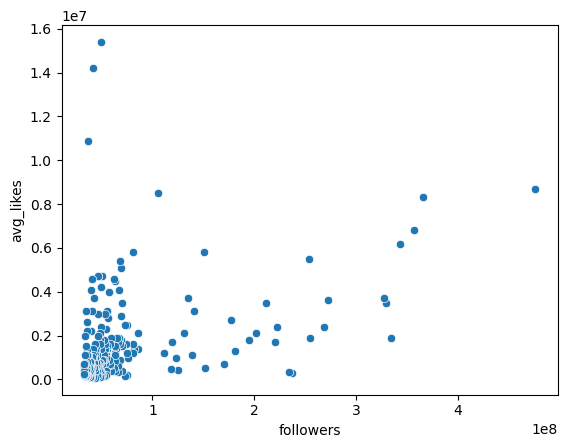

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="followers", y="avg_likes", data=df)
plt.show()

In [22]:
from scipy.stats import pearsonr

corr, p = pearsonr(df["followers"], df["avg_likes"])

print("Correlation:", corr)
print("P-value:", p)

Correlation: 0.34919526320577216
P-value: 4.023233692991437e-07


### Interpretation of Results

There is a moderate positive correlation (0.349) between the number of followers and the average number of likes.

The p-value is extremely small (p < 0.05), which indicates that this relationship is statistically significant.

This means that as the number of followers increases, the average number of likes also tends to increase.

However, since the correlation is not very high, follower count alone is not sufficient to fully explain engagement. Other factors may also influence engagement levels.

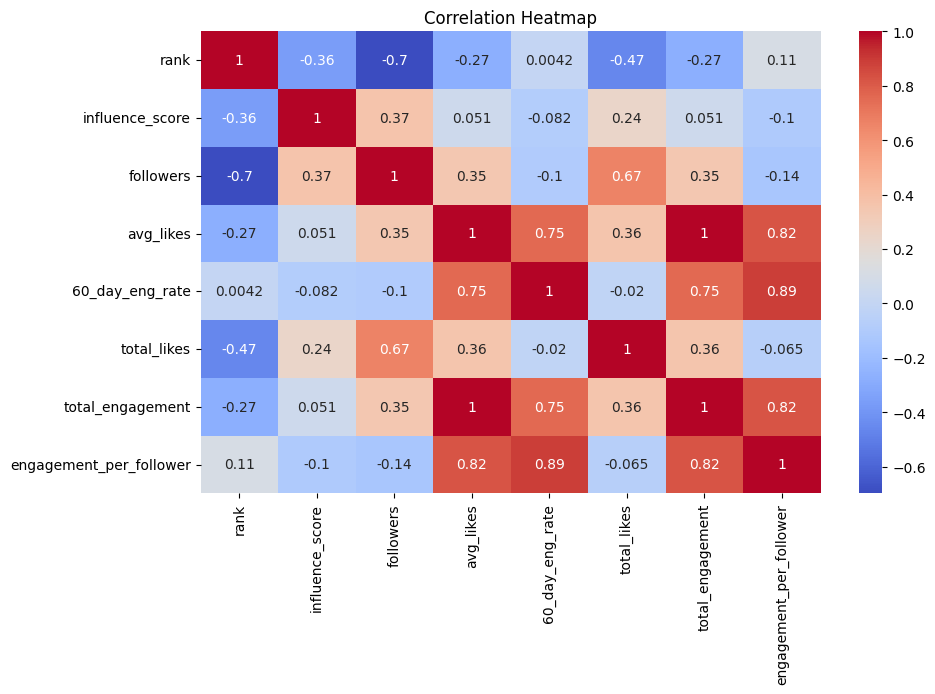

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("heatmap.png", bbox_inches="tight")
plt.show()

### Interpretation

This heatmap shows the relationships between different variables.

Red colors mean stronger positive relationships, while blue colors mean weaker or negative relationships.

For example, average likes and engagement rate have a strong positive relationship.

This means influencers with more likes usually have higher engagement.

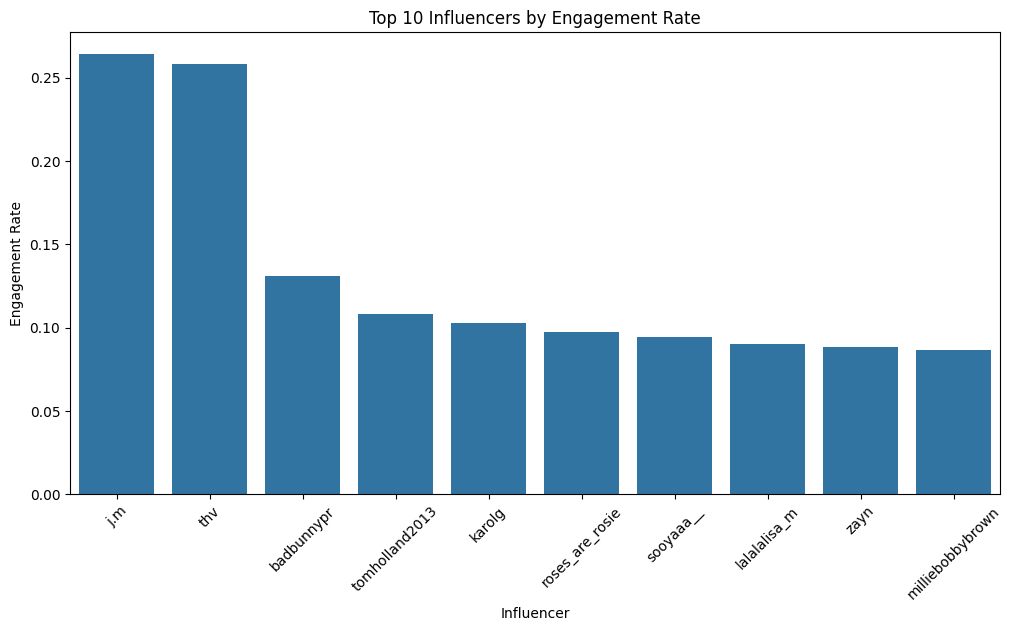

In [24]:
top_engagement = df.sort_values(by="60_day_eng_rate", ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x="channel_info", y="60_day_eng_rate", data=top_engagement)

plt.xticks(rotation=45)
plt.title("Top 10 Influencers by Engagement Rate")
plt.xlabel("Influencer")
plt.ylabel("Engagement Rate")
plt.savefig("top_engagement.png", bbox_inches="tight")

plt.show()


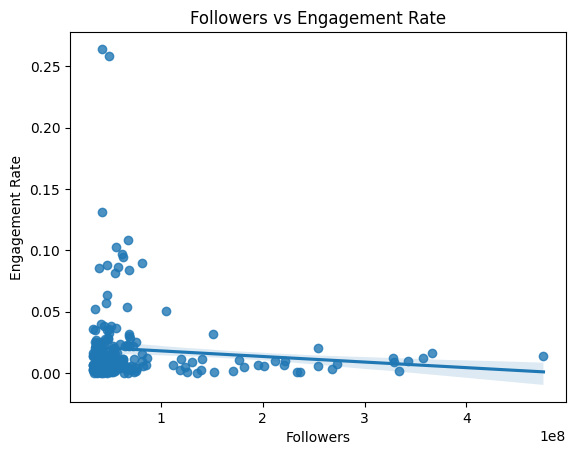

In [25]:
sns.regplot(x="followers", y="60_day_eng_rate", data=df)

plt.title("Followers vs Engagement Rate")
plt.xlabel("Followers")
plt.ylabel("Engagement Rate")
plt.savefig("followers_vs_engagement.png", bbox_inches="tight")

plt.show()

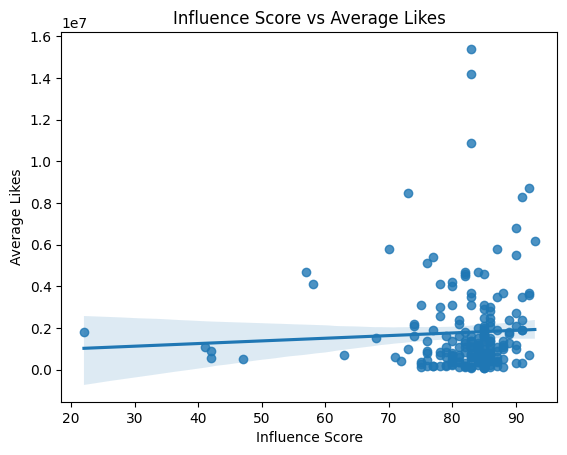

In [13]:
sns.regplot(x="influence_score", y="avg_likes", data=df)

plt.title("Influence Score vs Average Likes")
plt.xlabel("Influence Score")
plt.ylabel("Average Likes")

plt.show()

### Interpretation

This graph shows the connection between influence score and average likes.

People with higher influence scores usually get more likes.

But likes are not only affected by influence score. Content style and audience can also affect engagement.


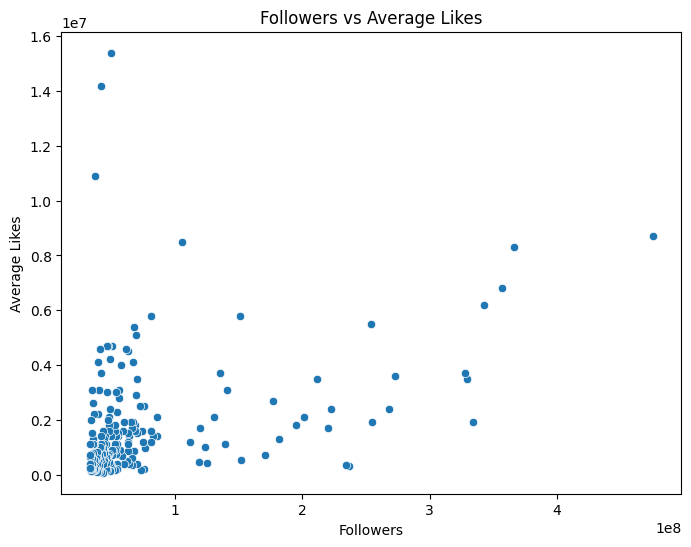

In [14]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="followers",
    y="avg_likes"
)

plt.title("Followers vs Average Likes")
plt.xlabel("Followers")
plt.ylabel("Average Likes")

plt.savefig("figures/followers_vs_likes.png", bbox_inches="tight")

plt.show()